# 01 — Data Exploration
**Milestone 2 — Healthcare Recommendation System**

Explores the 6 Synthea tables loaded into ClickHouse:
- Row counts and schema
- Null / missing value rates
- Patient demographics (age, gender, race)
- Condition distribution and prevalence
- Medication frequency
- Observation coverage
- Encounter patterns

**Run this notebook from the host machine** (not inside Docker).  
ClickHouse HTTP is exposed at `localhost:8123`.

```bash
# From the project root:
make explore
# or manually:
jupyter notebook notebooks/01_data_exploration.ipynb
```

In [1]:
# ── Dependencies ──────────────────────────────────────────────────────────────
# pip install clickhouse-connect pandas matplotlib seaborn jupyter
import clickhouse_connect
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import date

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

In [2]:
# ── Connect to ClickHouse ─────────────────────────────────────────────────────
# ClickHouse HTTP is exposed at localhost:8123 (see docker-compose.yml)
client = clickhouse_connect.get_client(
    host='localhost',
    port=8123,
    database='healthcare',
    username='healthcare_user',
    password='ch_secret_2026',
)

def q(sql):
    """Execute SQL and return a pandas DataFrame."""
    return client.query_df(sql)

# Quick connection test
print(client.query('SELECT version()').result_rows[0][0])

24.3.18.7


## 1. Row Counts

  patients                   11,679
  conditions                616,305
  medications             1,206,141
  observations           11,319,322
  encounters              1,054,071
  procedures              1,528,996


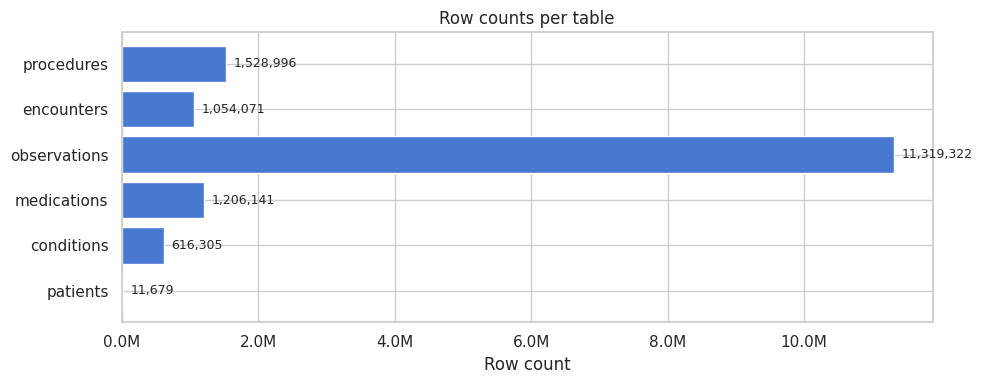

In [3]:
TABLES = ['patients', 'conditions', 'medications', 'observations', 'encounters', 'procedures']

counts = {}
for t in TABLES:
    n = client.query(f'SELECT count() FROM healthcare.{t}').result_rows[0][0]
    counts[t] = n
    print(f'  {t:<20} {n:>12,}')

df_counts = pd.DataFrame(list(counts.items()), columns=['table', 'rows'])

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(df_counts['table'], df_counts['rows'])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.set_xlabel('Row count')
ax.set_title('Row counts per table')
for bar, val in zip(bars, df_counts['rows']):
    ax.text(bar.get_width() + max(df_counts['rows']) * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{val:,}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 2. Patient Demographics

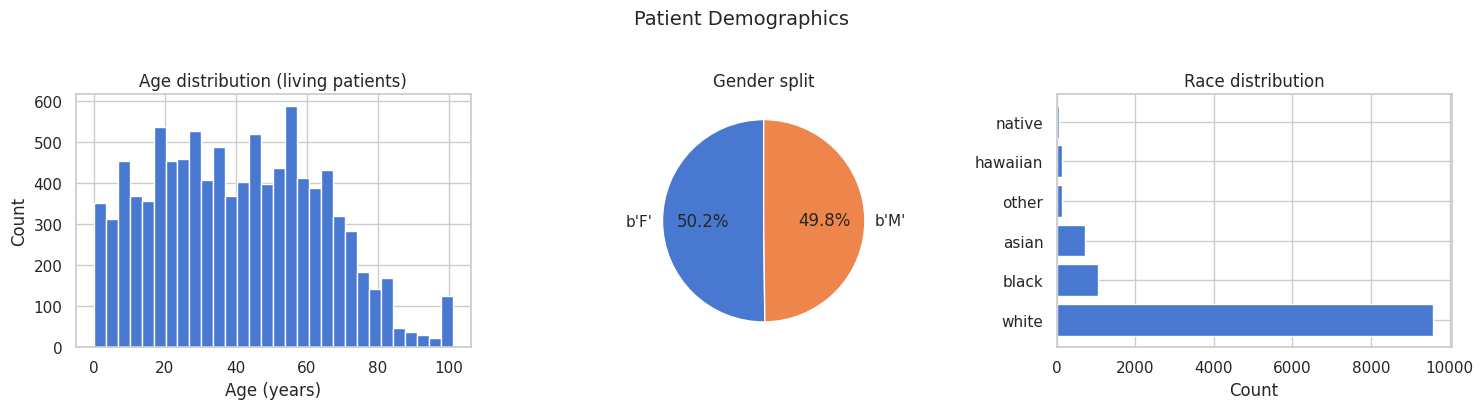


Age stats (living):
count   9,999.00
mean       40.50
std        23.30
min         0.00
25%        21.00
50%        40.00
75%        58.00
max       101.00
Name: age, dtype: float64


In [4]:
# Age distribution
df_age = q("""
    SELECT
        toInt32(dateDiff('year', birthdate, today())) AS age
    FROM healthcare.patients
    WHERE deathdate IS NULL
""")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Age histogram
axes[0].hist(df_age['age'].dropna(), bins=30, edgecolor='white')
axes[0].set_title('Age distribution (living patients)')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Count')

# Gender
df_gender = q("SELECT gender, count() AS n FROM healthcare.patients GROUP BY gender")
axes[1].pie(df_gender['n'], labels=df_gender['gender'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Gender split')

# Race
df_race = q("SELECT race, count() AS n FROM healthcare.patients GROUP BY race ORDER BY n DESC")
axes[2].barh(df_race['race'], df_race['n'])
axes[2].set_title('Race distribution')
axes[2].set_xlabel('Count')

plt.suptitle('Patient Demographics', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"\nAge stats (living):\n{df_age['age'].describe().round(1)}")

## 3. Condition Prevalence

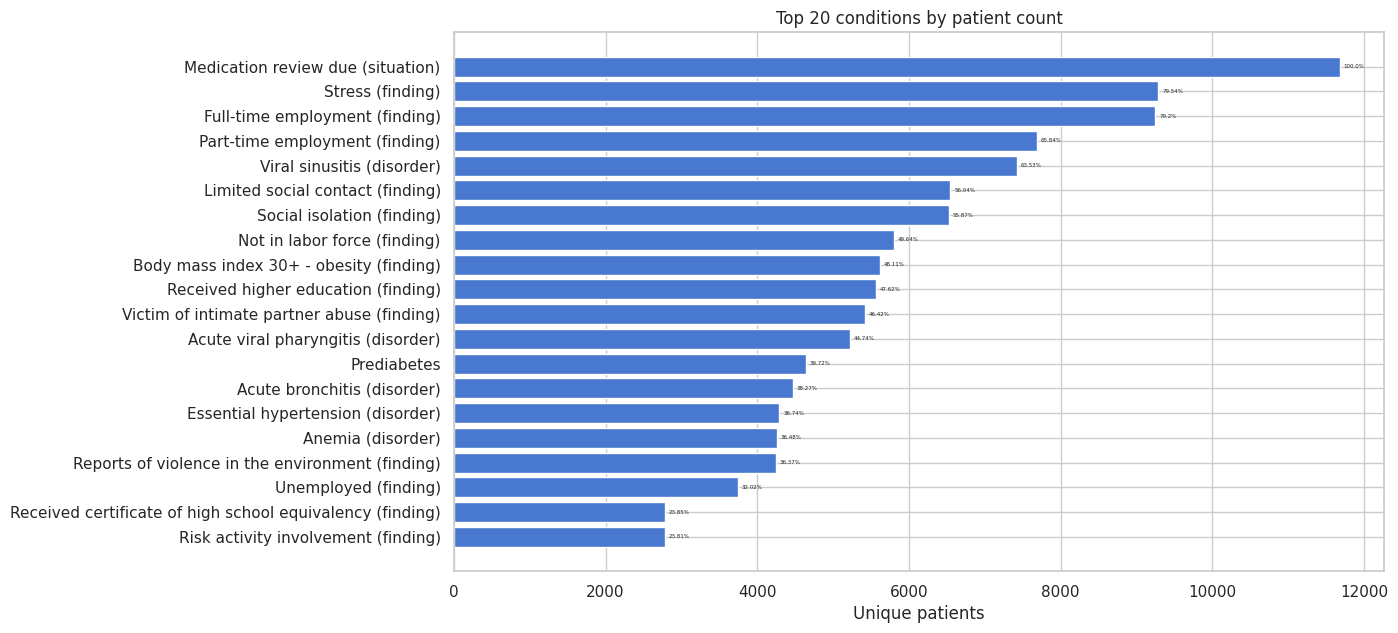

,description,patient_count,prevalence_pct
0,Medication review due (situation),11679,100.00
1,Stress (finding),9290,79.54
2,Full-time employment (finding),9250,79.20
3,Part-time employment (finding),7689,65.84
4,Viral sinusitis (disorder),7420,63.53
5,Limited social contact (finding),6545,56.04
6,Social isolation (finding),6525,55.87
7,Not in labor force (finding),5798,49.64
8,Body mass index 30+ - obesity (finding),5619,48.11
9,Received higher education (finding),5562,47.62


In [5]:
# Top 20 conditions by patient count
df_cond = q("""
    SELECT
        description,
        count(DISTINCT patient_id) AS patient_count,
        round(count(DISTINCT patient_id) * 100.0 /
              (SELECT count() FROM healthcare.patients), 2) AS prevalence_pct
    FROM healthcare.conditions
    GROUP BY description
    ORDER BY patient_count DESC
    LIMIT 20
""")

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(df_cond['description'][::-1], df_cond['patient_count'][::-1])
ax.set_xlabel('Unique patients')
ax.set_title('Top 20 conditions by patient count')
for bar, pct in zip(bars, df_cond['prevalence_pct'][::-1]):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f'{pct}%', va='center', fontsize=4)
# plt.tight_layout()
plt.show()

df_cond.head(10)

In [6]:
# Chronic condition flags used in feature engineering
chronic = {
    'Diabetes':          "code IN ('44054006','73211009')",
    'Hypertension':      "code = '59621000'",
    'Asthma':            "code = '195967001'",
    'Hyperlipidemia':    "code = '55822004'",
    'Coronary Disease':  "code IN ('53741008','413844008')",
}

print('Chronic condition prevalence:')
total_patients = client.query('SELECT count() FROM healthcare.patients').result_rows[0][0]
for name, where in chronic.items():
    n = client.query(f"""
        SELECT count(DISTINCT patient_id)
        FROM healthcare.conditions
        WHERE {where}
    """).result_rows[0][0]
    print(f'  {name:<25} {n:>6,}  ({n/total_patients*100:.1f}%)')

Chronic condition prevalence:
  Diabetes                     816  (7.0%)
  Hypertension               4,291  (36.7%)
  Asthma                        15  (0.1%)
  Hyperlipidemia             1,197  (10.2%)
  Coronary Disease               0  (0.0%)


## 4. Medication Frequency

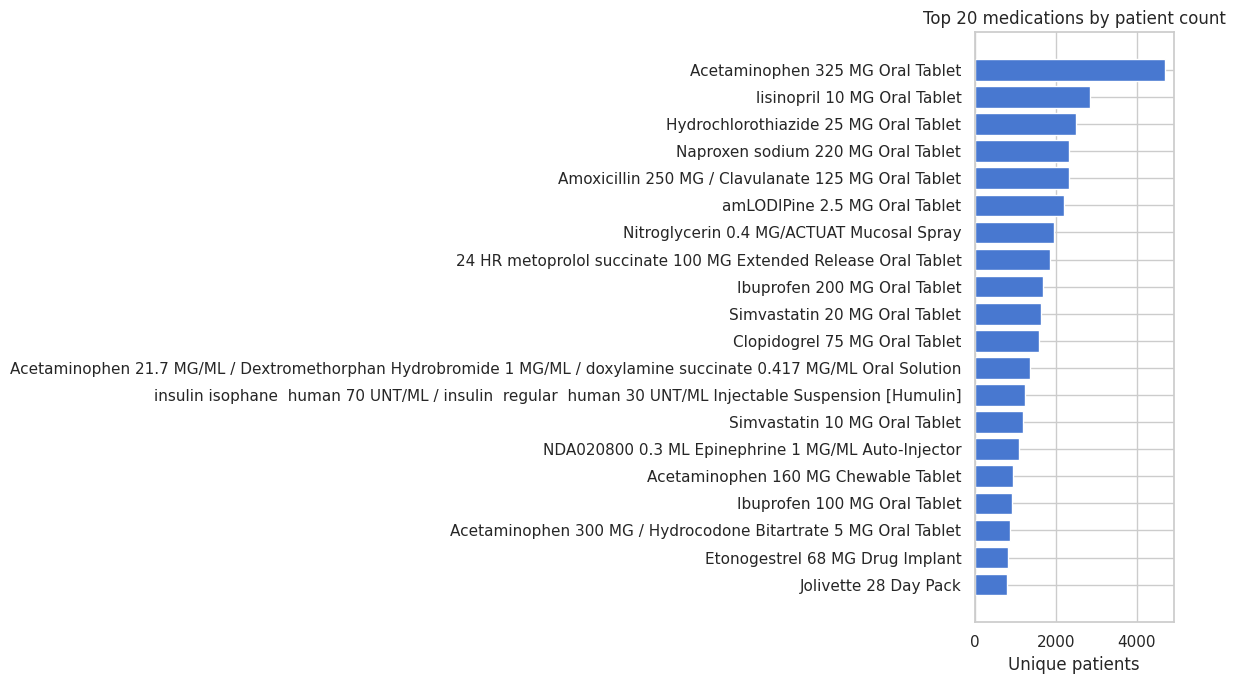

,description,patient_count,prescription_count
0,Acetaminophen 325 MG Oral Tablet,4680,6110
1,lisinopril 10 MG Oral Tablet,2840,175849
2,Hydrochlorothiazide 25 MG Oral Tablet,2493,158051
3,Naproxen sodium 220 MG Oral Tablet,2331,2687
4,Amoxicillin 250 MG / Clavulanate 125 MG Oral T...,2329,2663
5,amLODIPine 2.5 MG Oral Tablet,2206,130986
6,Nitroglycerin 0.4 MG/ACTUAT Mucosal Spray,1948,1948
7,24 HR metoprolol succinate 100 MG Extended Rel...,1866,1866
8,Ibuprofen 200 MG Oral Tablet,1684,1844
9,Simvastatin 20 MG Oral Tablet,1647,1647


In [7]:
df_meds = q("""
    SELECT
        description,
        count(DISTINCT patient_id) AS patient_count,
        count(*) AS prescription_count
    FROM healthcare.medications
    GROUP BY description
    ORDER BY patient_count DESC
    LIMIT 20
""")

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(df_meds['description'][::-1], df_meds['patient_count'][::-1])
ax.set_xlabel('Unique patients')
ax.set_title('Top 20 medications by patient count')
plt.tight_layout()
plt.show()

df_meds.head(10)

Medications per patient:
count   11,154.00
mean       108.10
std        313.60
min          1.00
25%          5.00
50%         17.00
75%         69.00
max     10,475.00
Name: num_medications, dtype: float64


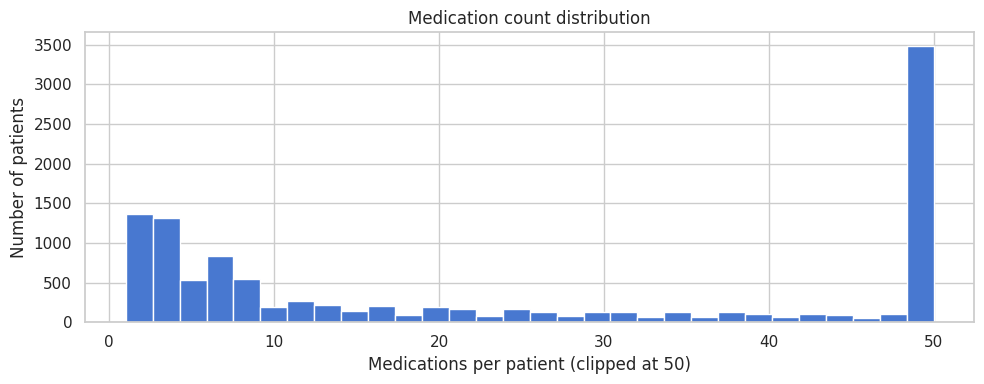

In [8]:
# Medications per patient distribution
df_med_dist = q("""
    SELECT
        patient_id,
        count(*) AS num_medications
    FROM healthcare.medications
    GROUP BY patient_id
""")

print(f"Medications per patient:\n{df_med_dist['num_medications'].describe().round(1)}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df_med_dist['num_medications'].clip(upper=50), bins=30, edgecolor='white')
ax.set_xlabel('Medications per patient (clipped at 50)')
ax.set_ylabel('Number of patients')
ax.set_title('Medication count distribution')
plt.tight_layout()
plt.show()

## 5. Null / Missing Value Analysis

In [9]:
# Check null rates for key columns used in feature engineering
null_checks = [
    ('patients',     'deathdate',       'IS NULL'),
    ('patients',     'lat',             'IS NULL'),
    ('patients',     'lon',             'IS NULL'),
    ('conditions',   'stop_date',       'IS NULL'),
    ('medications',  'stop_date',       'IS NULL'),
    ('medications',  'reasoncode',      "= ''"),
    ('encounters',   'reasoncode',      "= ''"),
    ('procedures',   'reasoncode',      "= ''"),
    ('observations', 'units',           "= ''"),
]

print(f'  {"Table":<15} {"Column":<25} {"Null/Empty":>12} {"Rate":>8}')
print('  ' + '-'*65)
for table, col, condition in null_checks:
    total = client.query(f'SELECT count() FROM healthcare.{table}').result_rows[0][0]
    nulls = client.query(
        f'SELECT count() FROM healthcare.{table} WHERE {col} {condition}'
    ).result_rows[0][0]
    rate = nulls / total * 100 if total > 0 else 0
    print(f'  {table:<15} {col:<25} {nulls:>12,} {rate:>7.1f}%')

  Table           Column                      Null/Empty     Rate
  -----------------------------------------------------------------
  patients        deathdate                        9,999    85.6%
  patients        lat                                  0     0.0%
  patients        lon                                  0     0.0%
  conditions      stop_date                      113,287    18.4%
  medications     stop_date                       34,244     2.8%
  medications     reasoncode                           0     0.0%
  encounters      reasoncode                           0     0.0%
  procedures      reasoncode                           0     0.0%
  observations    units                                0     0.0%


## 6. Encounter Patterns

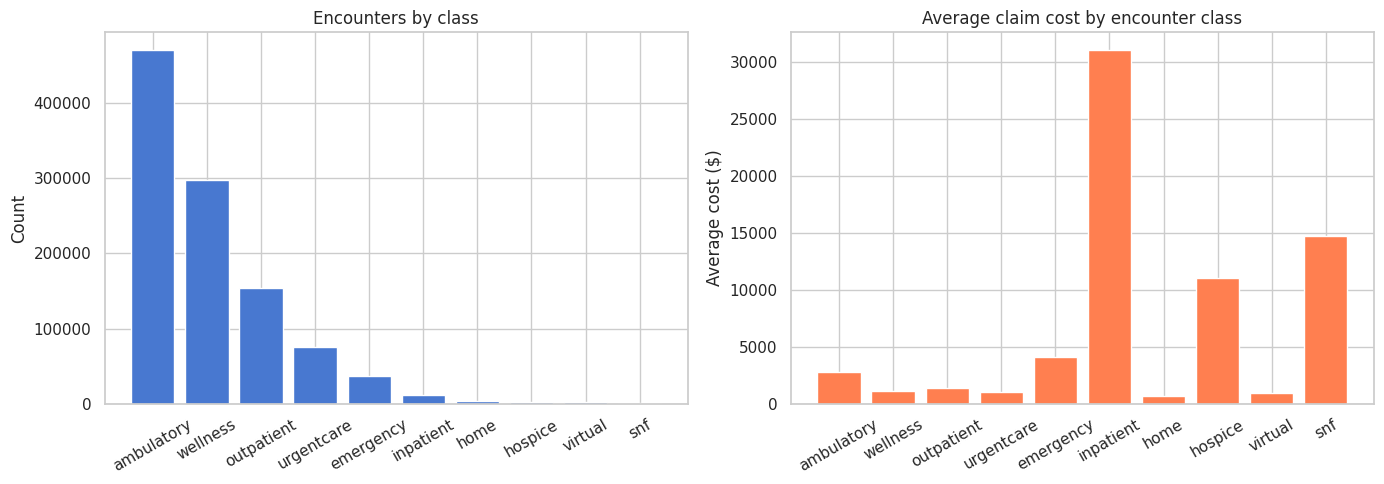

,encounterclass,n,avg_cost
0,ambulatory,469999,"2,763.09"
1,wellness,297310,"1,081.52"
2,outpatient,154230,"1,394.93"
3,urgentcare,75447,"1,051.35"
4,emergency,37156,"4,111.46"
5,inpatient,11090,"31,022.45"
6,home,3478,690.83
7,hospice,1931,"11,030.86"
8,virtual,1774,958.08
9,snf,1656,"14,705.01"


In [10]:
# Encounter class distribution
df_enc = q("""
    SELECT
        encounterclass,
        count(*) AS n,
        round(avg(total_claim_cost), 2) AS avg_cost
    FROM healthcare.encounters
    GROUP BY encounterclass
    ORDER BY n DESC
""")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(df_enc['encounterclass'], df_enc['n'])
axes[0].set_title('Encounters by class')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(df_enc['encounterclass'], df_enc['avg_cost'], color='coral')
axes[1].set_title('Average claim cost by encounter class')
axes[1].set_ylabel('Average cost ($)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

df_enc

Encounters per patient:
count   11,679.00
mean        90.30
std        147.50
min          1.00
25%         26.00
50%         47.00
75%         79.00
max      1,461.00
Name: num_encounters, dtype: float64


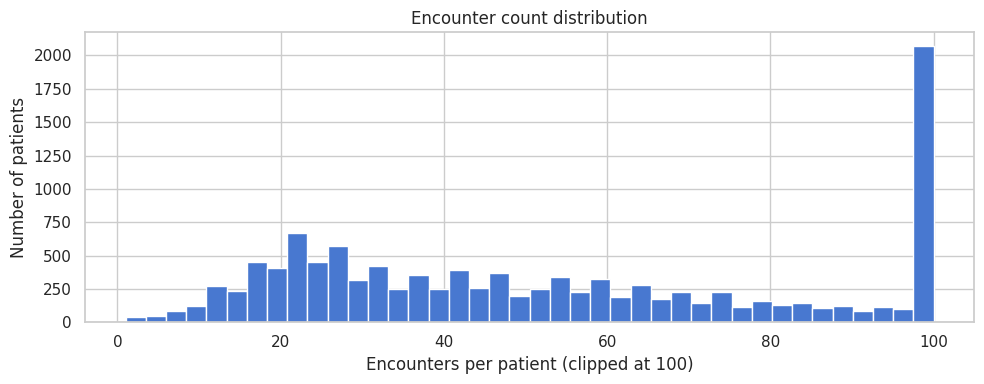

In [11]:
# Encounters per patient
df_enc_per_pt = q("""
    SELECT patient_id, count(*) AS num_encounters
    FROM healthcare.encounters
    GROUP BY patient_id
""")

print(f"Encounters per patient:\n{df_enc_per_pt['num_encounters'].describe().round(1)}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df_enc_per_pt['num_encounters'].clip(upper=100), bins=40, edgecolor='white')
ax.set_xlabel('Encounters per patient (clipped at 100)')
ax.set_ylabel('Number of patients')
ax.set_title('Encounter count distribution')
plt.tight_layout()
plt.show()

## 7. Observation Coverage

Key observation coverage:
  BMI                  11,391  (97.5%)
  Systolic BP          11,679  (100.0%)
  Diastolic BP         11,679  (100.0%)
  Glucose               5,483  (46.9%)
  Cholesterol           7,589  (65.0%)


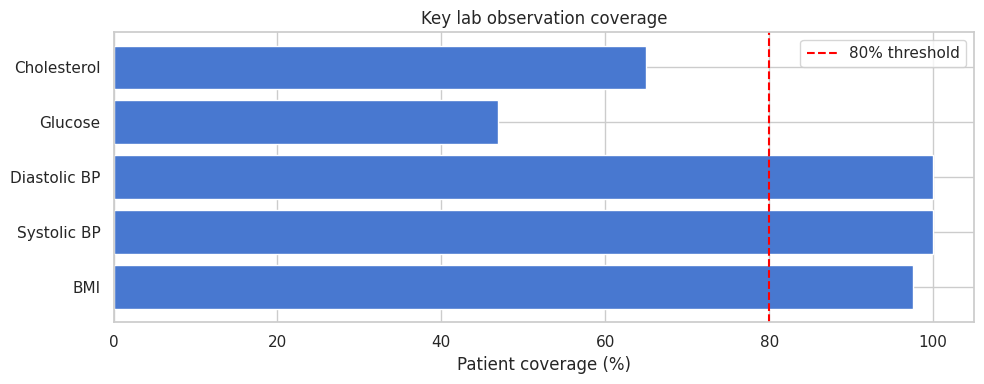

In [12]:
# Coverage of key lab observations used in feature engineering
LOINC = {
    'BMI':             '39156-5',
    'Systolic BP':     '8480-6',
    'Diastolic BP':    '8462-4',
    'Glucose':         '2339-0',
    'Cholesterol':     '2093-3',
}

total_patients = client.query('SELECT count() FROM healthcare.patients').result_rows[0][0]

print('Key observation coverage:')
coverage = []
for name, loinc in LOINC.items():
    n = client.query(f"""
        SELECT count(DISTINCT patient_id)
        FROM healthcare.observations
        WHERE code = '{loinc}'
    """).result_rows[0][0]
    pct = n / total_patients * 100
    coverage.append({'Observation': name, 'LOINC': loinc, 'Patients': n, 'Coverage %': pct})
    print(f'  {name:<20} {n:>6,}  ({pct:.1f}%)')

df_cov = pd.DataFrame(coverage)

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(df_cov['Observation'], df_cov['Coverage %'])
ax.set_xlabel('Patient coverage (%)')
ax.set_title('Key lab observation coverage')
ax.axvline(x=80, color='red', linestyle='--', label='80% threshold')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Feature Engineering Preview

In [ ]:
# Show what patient_features will look like after Milestone 2 Spark jobs
# This queries ClickHouse directly and computes a mini version for 100 patients

df_preview = q("""
    SELECT
        p.patient_id,
        toInt32(dateDiff('year', p.birthdate, today()))   AS age,
        if(p.gender = 'M', 1, 0)                         AS gender_encoded,
        count(DISTINCT c.code)                            AS num_unique_conditions,
        count(DISTINCT m.code)                            AS num_medications,
        count(DISTINCT e.encounter_id)                    AS num_encounters,
        maxIf(1, c.code IN ('44054006','73211009'))       AS has_diabetes,
        maxIf(1, c.code = '59621000')                    AS has_hypertension,
        maxIf(1, c.code = '195967001')                   AS has_asthma
    FROM healthcare.patient_features p
    LEFT JOIN healthcare.conditions  c ON p.patient_id = c.patient_id
    LEFT JOIN healthcare.medications m ON p.patient_id = m.patient_id
    LEFT JOIN healthcare.encounters  e ON p.patient_id = e.patient_id
    GROUP BY p.patient_id, p.birthdate, p.gender
    LIMIT 100
""")

print(f'Preview shape: {df_preview.shape}')
df_preview.describe().round(2)

In [ ]:
# Correlation heatmap of numeric features
numeric_cols = ['age', 'gender_encoded', 'num_unique_conditions',
                'num_medications', 'num_encounters',
                'has_diabetes', 'has_hypertension', 'has_asthma']

fig, ax = plt.subplots(figsize=(9, 7))
corr = df_preview[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('Feature correlation (preview — 100 patients)')
plt.tight_layout()
plt.show()

## 9. Exploration Summary

Run the cell below to get a clean summary of findings to guide the cleaning and feature engineering jobs.

In [ ]:
print('=' * 60)
print('DATA EXPLORATION SUMMARY')
print('=' * 60)

for t, n in counts.items():
    print(f'  {t:<20} {n:>12,} rows')

print()
print('Key cleaning decisions for clean.py:')
print('  patients:     drop null BIRTHDATE/GENDER; cast dates + numerics')
print('  conditions:   drop null PATIENT/CODE; parse dates')
print('  medications:  fill null STOP with 9999-12-31 (still active)')
print('  observations: keep TYPE=numeric only; cast VALUE to Double')
print('  encounters:   cast timestamps + costs; dedup on Id')
print('  procedures:   drop null PATIENT/CODE; cast dates + costs')

print()
print('Key feature engineering decisions for feature_engineering.py:')
print('  condition_vector: multi-hot Array(Float32) over top-50 conditions')
print('  medication_flags: multi-hot Array(Float32) over top-50 medications')
print('  lab observations: BMI, BP, glucose, cholesterol (latest value)')
print('  chronic flags:    diabetes, hypertension, asthma, hyperlipidemia, CAD')
print('=' * 60)